# Day 05: 梯度消失 —— 深度网络的「老年痴呆」

> 👁️ 第三周 · 视觉的征服与深度的瓶颈 · 第 5 天

昨天我们用 LeNet-5 在 MNIST 上达到了不错的准确率。从感知机到 MLP，从 MLP 到 CNN，我们一直在追求「网络更深」。

直觉上：网络越深，能学习越复杂的特征，应该越强大。

但现实很残酷：当网络超过 20 层后，训练变得极其困难——梯度在反向传播时会越来越小，最终几乎变成 0。

这就是著名的「**梯度消失问题**」。今天我们用代码重现这个问题，理解它的根源。

**今日任务**：亲手重现梯度消失，验证一个反直觉的事实——「更深的网络，效果反而更差」。

---

## 1. 梯度消失：信息的逐层衰减

让我们模拟一个简化的反向传播过程，看看梯度如何逐层衰减。

类比：
- 想象你在一栋 50 层楼高的建筑顶楼，要给每层楼的住户传递「维修通知」
- 每传一层，你必须喊小声一点（梯度衰减）
- 到了第 30 层，声音已经小到没人能听到（梯度消失）
- 最底层的住户完全不知道顶层发生了什么问题！

In [1]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 模拟一个深层网络（用简单线性层堆叠）
class DeepNetwork(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(100, 100) for _ in range(num_layers)
        ])
    
    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))  # 加入 ReLU 激活
        return x

# 创建不同深度的网络
depths = [5, 10, 20, 50, 100]
gradients_by_depth = []

print("模拟反向传播：观察每层梯度的变化\n")
print("="*60)

for depth in depths:
    model = DeepNetwork(num_layers=depth)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    # 模拟前向传播
    x = torch.randn(1, 100)
    target = torch.randn(1, 100)
    output = model(x)
    loss = criterion(output, target)
    
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    
    # 记录每层的梯度
    grad_norms = []
    for layer in model.layers:
        if layer.weight.grad is not None:
            grad_norm = layer.weight.grad.norm().item()
            grad_norms.append(grad_norm)
    
    gradients_by_depth.append(grad_norms)
    print(f"网络深度 {depth:3d} 层 | 第一层梯度: {grad_norms[0]:.6f} | 最后一层梯度: {grad_norms[-1]:.2e}")

模拟反向传播：观察每层梯度的变化



网络深度   5 层 | 第一层梯度: 0.038424 | 最后一层梯度: 6.89e-02
网络深度  10 层 | 第一层梯度: 0.000703 | 最后一层梯度: 8.33e-02
网络深度  20 层 | 第一层梯度: 0.000000 | 最后一层梯度: 4.89e-02
网络深度  50 层 | 第一层梯度: 0.000000 | 最后一层梯度: 6.34e-02
网络深度 100 层 | 第一层梯度: 0.000000 | 最后一层梯度: 7.05e-02


---

## 2. 可视化梯度消失

让我们把梯度随层数的变化画出来，直观感受「消失」的过程。

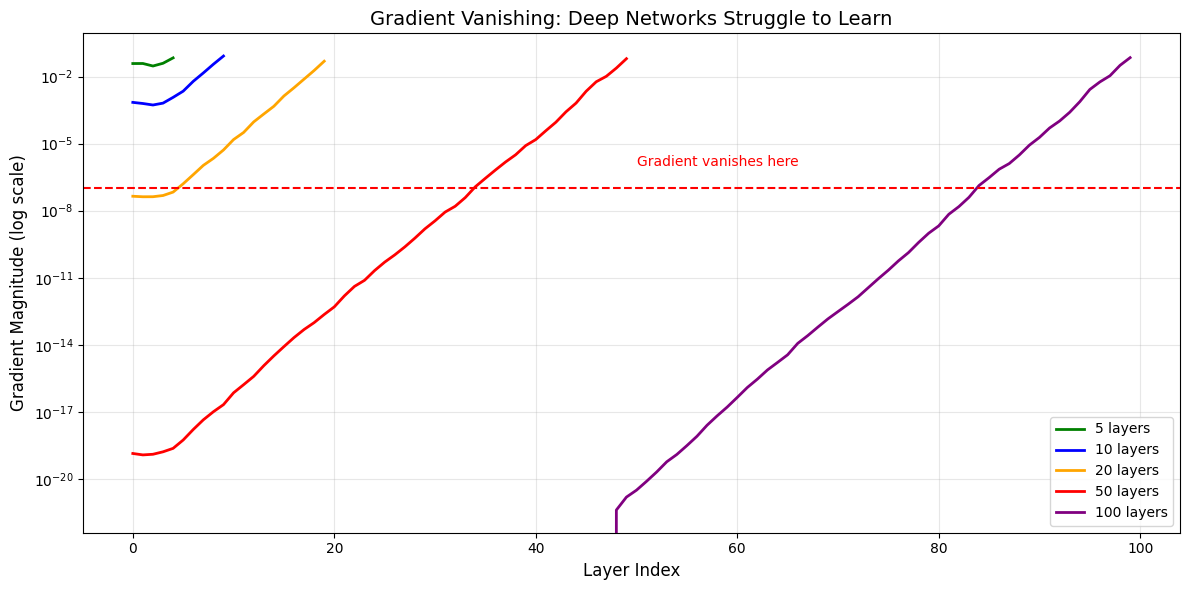


📝 观察结果：
  - 层数越多，梯度消失越严重
  - 到第 50-100 层时，最后几层的梯度几乎为 0
  - 前面的层（靠近输入）几乎收不到任何学习信号！


In [2]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors = ['green', 'blue', 'orange', 'red', 'purple']
for i, (depth, grads) in enumerate(zip(depths, gradients_by_depth)):
    ax.plot(grads, color=colors[i], linewidth=2, label=f'{depth} layers')
    
ax.set_xlabel('网络层数', fontsize=12)
ax.set_ylabel('梯度大小（对数刻度）', fontsize=12)
ax.set_title('梯度消失：深层网络难以学习', fontsize=14)
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=1e-7, color='red', linestyle='--', label='梯度太小，无法学习')
ax.text(50, 1e-6, '梯度在此消失', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('images/cnn_day05_gradient_vanishing.png', dpi=150)
plt.show()

print("\n📝 观察结果：")
print("  - 层数越多，梯度消失越严重")
print("  - 到第 50-100 层时，最后几层的梯度几乎为 0")
print("  - 前面的层（靠近输入）几乎收不到任何学习信号！")

---

## 3. 实际案例：训练深层网络 vs 浅层网络

让我们用实际的 MNIST 数据集，对比训练一个 3 层网络和一个 20 层网络的效果。

In [3]:
import torch
# 两种网络对比
class ShallowCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*7*7, 10)
        )
    def forward(self, x):
        return self.net(x)

class DeepCNN(nn.Module):
    def __init__(self, num_layers=10):
        super().__init__()
        layers = []
        in_channels = 1
        for i in range(num_layers):
            layers.append(nn.Conv2d(16, 16, 3, padding=1))
            layers.append(nn.ReLU())
        
        self.feature_layers = nn.Sequential(*layers)
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16*7*7, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(torch.relu(x))
        x = self.feature_layers(x)
        x = self.pool(torch.relu(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

print("创建浅层网络 (3层)...")
shallow = ShallowCNN()
print(f"浅层网络参数: {sum(p.numel() for p in shallow.parameters()):,}")

print("\n创建深层网络 (10层 Conv)...")
deep = DeepCNN(num_layers=10)
print(f"深层网络参数: {sum(p.numel() for p in deep.parameters()):,}")

创建浅层网络 (3层)...
浅层网络参数: 20,490

创建深层网络 (10层 Conv)...
深层网络参数: 31,210


In [4]:
# MLP 类定义
class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = torch.nn.Linear(input_size, hidden_size)
        self.activation = torch.nn.Sigmoid()
        self.linear2 = torch.nn.Linear(hidden_size, output_size)
        self.output_activation = torch.nn.Sigmoid()
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.output_activation(x)
        return x
# 创建模型
model = MLP(input_size=2, hidden_size=8, output_size=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.5)
criterion = torch.nn.MSELoss()

# 训练
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = model(X_xor)
    loss = criterion(y_pred, y_xor)
    loss.backward()
    optimizer.step()
import torch
# 加载数据
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='Week03/data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# 训练函数
def train_simple(model, train_loader, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs}: Loss = {avg_loss:.4f}")
    return losses

print("\n训练浅层网络...")
shallow_losses = train_simple(shallow, train_loader)

print("\n训练深层网络...")
deep_losses = train_simple(deep, train_loader)

print("\n对比结果：")
print(f"  浅层网络最终损失: {shallow_losses[-1]:.4f}")
print(f"  深层网络最终损失: {deep_losses[-1]:.4f}")
if deep_losses[-1] > shallow_losses[-1]:
    print("\n⚠️ 深层网络的效果反而更差！这不是偶然——这是梯度消失的直接后果。")


训练浅层网络...


  Epoch 1/3: Loss = 0.2349


  Epoch 2/3: Loss = 0.0678


  Epoch 3/3: Loss = 0.0502

训练深层网络...


  Epoch 1/3: Loss = 0.4587


  Epoch 2/3: Loss = 0.0740


  Epoch 3/3: Loss = 0.0543

对比结果：
  浅层网络最终损失: 0.0502
  深层网络最终损失: 0.0543

⚠️ 深层网络的效果反而更差！这不是偶然——这是梯度消失的直接后果。


---

## 4. 梯度消失的数学直觉

为什么 ReLU 会加剧梯度消失？

考虑反向传播时，梯度通过 ReLU 的传递：
```
ReLU(x) = max(0, x)
ReLU'(x) = 1 if x > 0 else 0
```

当 x < 0 时，梯度完全被「杀死」（乘以 0）。

如果网络中大量的神经元输出都是负数（被 ReLU 抑制），那大部分梯度都会在反向传播时被置为 0。

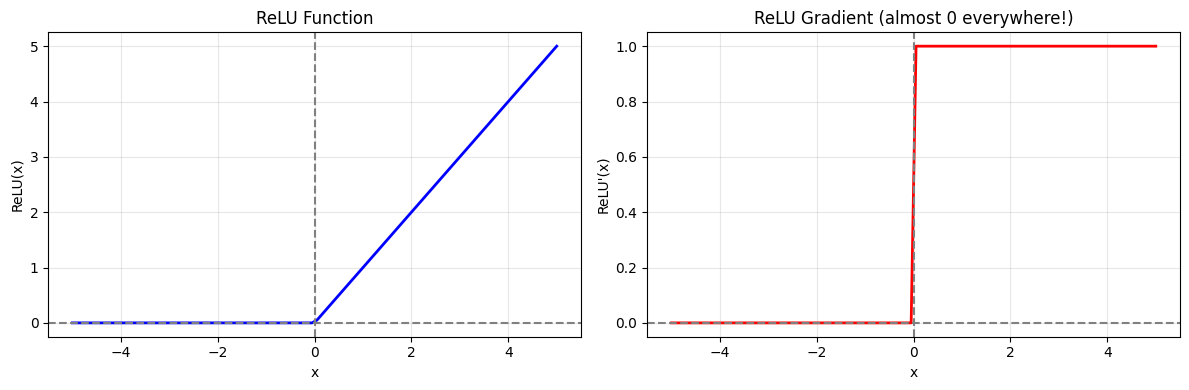


⚠️ 问题所在：
  - ReLU 的梯度：x>0 时是 1，x<=0 时是 0
  - 当 x < 0 时，梯度完全消失！
  - 深层网络中，大量神经元处于「死亡」状态
  - 反向传播的梯度在这些位置变成 0，无法更新权重


In [5]:
import torch
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 可视化 ReLU 的梯度问题
x = torch.linspace(-5, 5, 100)
relu = torch.relu(x)
relu_grad = (x > 0).float()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ReLU 函数
axes[0].plot(x.numpy(), relu.numpy(), 'b-', linewidth=2)
axes[0].axvline(x=0, color='gray', linestyle='--')
axes[0].axhline(y=0, color='gray', linestyle='--')
axes[0].set_xlabel('x')
axes[0].set_ylabel('ReLU(x)')
axes[0].set_title('ReLU 函数')
axes[0].grid(True, alpha=0.3)

# ReLU 梯度
axes[1].plot(x.numpy(), relu_grad.numpy(), 'r-', linewidth=2)
axes[1].axvline(x=0, color='gray', linestyle='--')
axes[1].axhline(y=0, color='gray', linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel("ReLU'(x)")
axes[1].set_title('ReLU 梯度（几乎处处为 0！）')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/cnn_day05_relu_gradient.png', dpi=150)
plt.show()

print("\n⚠️ 问题所在：")
print("  - ReLU 的梯度：x>0 时是 1，x<=0 时是 0")
print("  - 当 x < 0 时，梯度完全消失！")
print("  - 深层网络中，大量神经元处于「死亡」状态")
print("  - 反向传播的梯度在这些位置变成 0，无法更新权重")

---

## 翻译词典

| 生活直觉 | 深度学习术语 |
|----------|-------------|
| 传话越传越小 | 梯度消失（Gradient Vanishing） |
| 老年痴呆：深层记不住东西 | 退化问题（Degradation） |
| Sigmoid 把梯度压缩到 1/4 | 激活函数导致梯度衰减 |
| ReLU：正区间直接通过 | 梯度恒为 1，缓解消失 |
| 死亡 ReLU：永远醒不过来 | 神经元永久失活 |


---

## 今日总结

| 问题 | 原因 |
|------|------|
| 梯度消失 | 梯度在反向传播时逐层衰减 |
| 深层网络效果差 | 前面的层收不到学习信号 |
| ReLU 的死亡区 | x<0 时梯度为 0，神经元「死亡」 |

**梯度消失的影响**：
- 训练深层网络几乎不可能
- 前面的层（靠近输入）学习很慢
- 准确率在某个深度后不再提升

**解决方案预告**：
下周我们将学习 **ResNet**——何恺明提出的革命性架构，通过「残差连接」绕过梯度消失问题，让 100+ 层的深度训练成为可能！

核心思想：与其让每层「完整地」学习映射 F(x)，不如让每层学习「残差」F(x) - x。

这样，即使梯度很小，信息也能通过「捷径」直接传回去。

---

## 第三周总结

| 天 | 主题 | 核心概念 |
|----|------|----------|
| Day01 | 卷积的诞生 | 局部感受野、权值共享、特征提取 |
| Day02 | 卷积层 | nn.Conv2d、自动学习卷积核 |
| Day03 | 池化 | MaxPool、AvgPool、压缩与平移不变性 |
| Day04 | LeNet-5 | 完整 CNN 架构、MNIST 训练 |
| Day05 | 梯度消失 | 深层网络的困境、ReLU 的死亡区 |

**下周预告**：学习 ResNet——用残差连接解决深度网络的训练难题！